# 2. The ML Workflow (Data → Model → Prediction)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Tiny dataset: predict "Passed" based on Hours Studied and Attendance
data = [
    {"hours": 1, "attendance": 60, "passed": 0},
    {"hours": 2, "attendance": 65, "passed": 0},
    {"hours": 3, "attendance": 70, "passed": 0},
    {"hours": 4, "attendance": 75, "passed": 1},
    {"hours": 5, "attendance": 80, "passed": 1},
    {"hours": 6, "attendance": 85, "passed": 1},
    {"hours": 7, "attendance": 90, "passed": 1},
    {"hours": 2, "attendance": 80, "passed": 0},
    {"hours": 8, "attendance": 55, "passed": 0},
    {"hours": 9, "attendance": 92, "passed": 1},
]

df = pd.DataFrame(data)

X = df[["hours", "attendance"]]   # features
y = df["passed"]                 # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print(X_train.head())

Train rows: 8
Test rows : 2
   hours  attendance
5      6          85
0      1          60
7      2          80
2      3          70
9      9          92


# 3. Data Basics (Features, Target, Leakage)

In [2]:
import pandas as pd

df = pd.DataFrame([
    {"occupation": "Govt"},
    {"occupation": "Private"},
    {"occupation": "Self"},
    {"occupation": "Govt"},
])

encoded = pd.get_dummies(df["occupation"], prefix="occ")
print(encoded)


   occ_Govt  occ_Private  occ_Self
0      True        False     False
1     False         True     False
2     False        False      True
3      True        False     False


# 4. Evaluation Metrics (How to know - how model is good?)

In [3]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Actual vs Predicted (tiny example)
y_true = [1, 0, 1, 1, 0, 0, 1, 0]
y_pred = [1, 0, 0, 1, 0, 1, 1, 0]

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))


Confusion Matrix:
 [[3 1]
 [1 3]]
Accuracy : 0.75
Precision: 0.75
Recall   : 0.75
F1 Score : 0.75


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = [2.0, 2.5, 3.0, 3.5]
y_pred = [2.2, 2.4, 2.9, 3.6]

print("MAE:", mean_absolute_error(y_true, y_pred))
print("MSE:", mean_squared_error(y_true, y_pred))
print("R2 :", r2_score(y_true, y_pred))


MAE: 0.1250000000000001
MSE: 0.01750000000000003
R2 : 0.944


# 5. Decision Trees (CART) and Gini Impurity

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Tiny dataset (static)
data = [
    {"exp": 5, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 5, "state": "AP", "qualification": "B-Tech", "hr_approved": 1},
    {"exp":10, "state": "UP", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 5, "state": "UP", "qualification": "PhD",    "hr_approved": 0},
    {"exp": 7, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 2, "state": "MH", "qualification": "B-Tech", "hr_approved": 0},
    {"exp": 8, "state": "KA", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 6, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 4, "state": "AP", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 9, "state": "TN", "qualification": "PhD",    "hr_approved": 0},
]

df = pd.DataFrame(data)
X = df[["exp", "state", "qualification"]]
y = df["hr_approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

cat_cols = ["state", "qualification"]
num_cols = ["exp"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=2,
    random_state=7
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
print(classification_report(y_test, pred))

# ===== ADDITION: Predict on unseen data =====
# Example: a new candidate with 6 years experience, from Maharashtra ('MH') with B-Tech
unseen = pd.DataFrame({"exp": [6], "state": ["MH"], "qualification": ["B-Tech"]})
unseen_pred = pipe.predict(unseen)[0]
unseen_proba = pipe.predict_proba(unseen)[0, 1]  # probability of class 1 (hr_approved)

print("\n--- Unseen data prediction ---")
print(f"Input: exp=6, state=MH, qualification=B-Tech")
print(f"Predicted outcome: {'Approved' if unseen_pred == 1 else 'Not Approved'}")
print(f"Probability of approval: {unseen_proba:.2f}")


              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


--- Unseen data prediction ---
Input: exp=6, state=MH, qualification=B-Tech
Predicted outcome: Approved
Probability of approval: 1.00


# 6. Random Forest (Bagging + Voting)

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Reuse the same tiny HR dataset
data = [
    {"exp": 5, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 5, "state": "AP", "qualification": "B-Tech", "hr_approved": 1},
    {"exp":10, "state": "UP", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 5, "state": "UP", "qualification": "PhD",    "hr_approved": 0},
    {"exp": 7, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 2, "state": "MH", "qualification": "B-Tech", "hr_approved": 0},
    {"exp": 8, "state": "KA", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 6, "state": "TN", "qualification": "B-Tech", "hr_approved": 1},
    {"exp": 4, "state": "AP", "qualification": "MBA",    "hr_approved": 0},
    {"exp": 9, "state": "TN", "qualification": "PhD",    "hr_approved": 0},
]

df = pd.DataFrame(data)
X = df[["exp", "state", "qualification"]]
y = df["hr_approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), ["state", "qualification"])],
    remainder="passthrough"
)

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=7,
    max_depth=4
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", rf)])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# ===== ADDITION: Predict on unseen data =====
# Example: a new candidate with 6 years experience, from 'MH' with qualification 'B-Tech'
unseen = pd.DataFrame({"exp": [6], "state": ["MH"], "qualification": ["B-Tech"]})
unseen_pred = pipe.predict(unseen)[0]
unseen_proba = pipe.predict_proba(unseen)[0, 1]  # probability of class 1 (hr_approved)

print("\n--- Unseen data prediction ---")
print(f"Input: exp=6, state=MH, qualification=B-Tech")
print(f"Predicted outcome: {'Approved' if unseen_pred == 1 else 'Not Approved'}")
print(f"Probability of approval: {unseen_proba:.2f}")


Accuracy: 0.6666666666666666

--- Unseen data prediction ---
Input: exp=6, state=MH, qualification=B-Tech
Predicted outcome: Approved
Probability of approval: 0.74


# 7. Linear Regression (Predict a Number)

MODEL EVALUATION
Slope (coefficient): 0.2452
Intercept: 2.0152
MAE: 0.0870
R² Score: 0.9710

TEST SET RESULTS:
------------------------------
 Hours  Actual GPA  Predicted GPA     Error
     7         3.9       3.731481  0.168519
     2         2.5       2.505556 -0.005556

UNSEEN DATA PREDICTION

Predictions for unseen study hours:
----------------------------------------
Study Hours:  0.0 → Predicted GPA: 2.015
Study Hours:  2.5 → Predicted GPA: 2.628
Study Hours:  7.5 → Predicted GPA: 3.854
Study Hours: 11.0 → Predicted GPA: 4.712
Study Hours: 12.0 → Predicted GPA: 4.957
Study Hours: 15.0 → Predicted GPA: 5.693


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


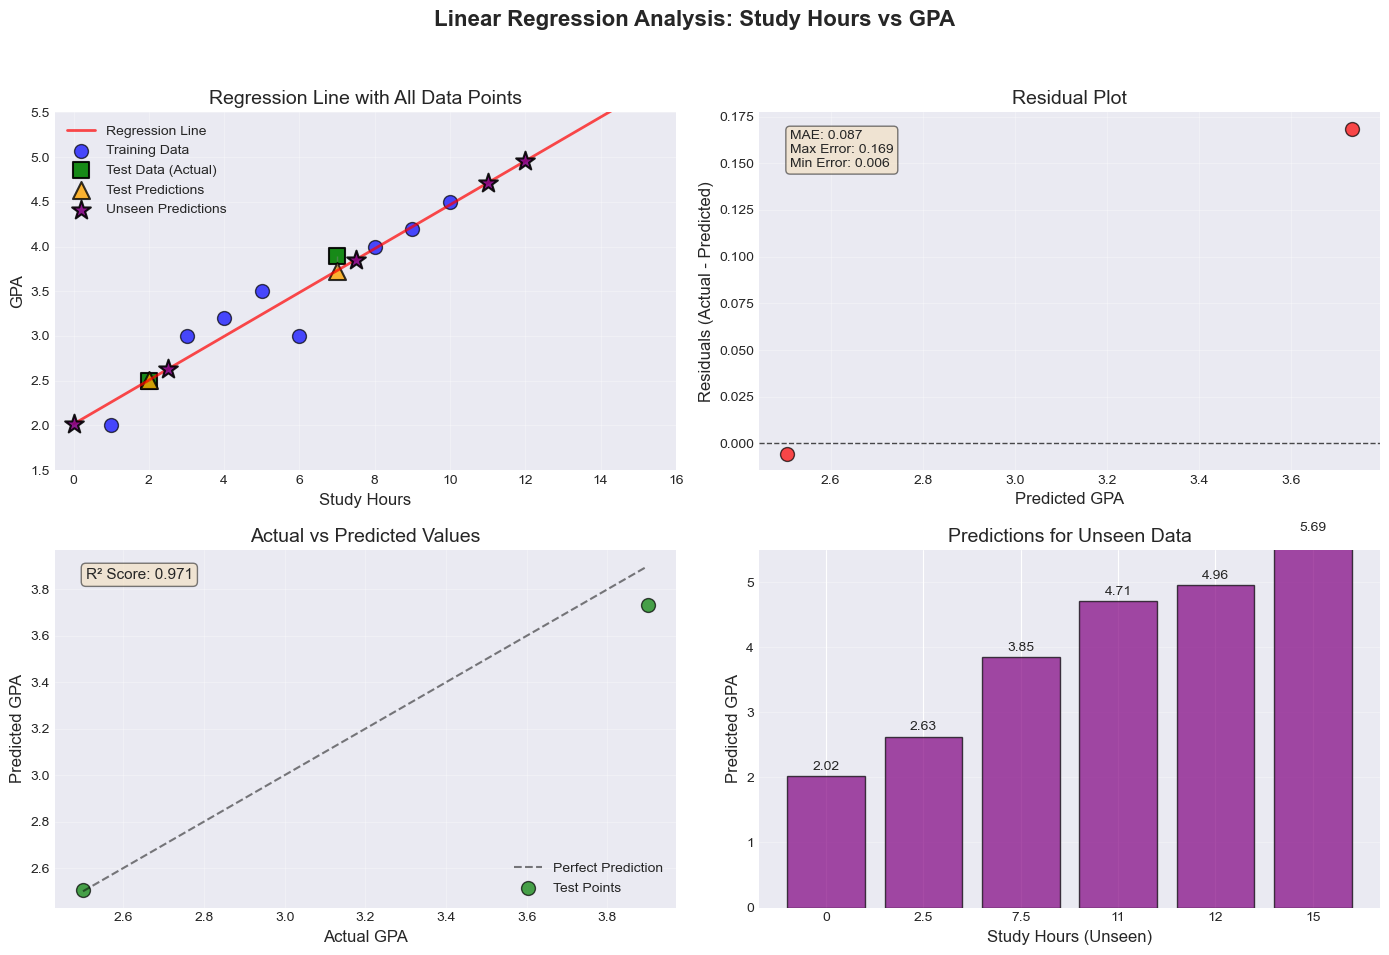


DATA SUMMARY
Total data points: 10
Training samples: 8
Test samples: 2
Unseen predictions: 6

Training range: 1 to 10 hours
Test range: 2 to 7 hours
Unseen range: 0 to 15 hours

Regression Equation: GPA = 2.015 + 0.245 * Hours


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tiny dataset: study hours → GPA
data = [
    {"hours": 1, "gpa": 2.0},
    {"hours": 2, "gpa": 2.5},
    {"hours": 3, "gpa": 3.0},
    {"hours": 5, "gpa": 3.5},
    {"hours": 6, "gpa": 3.0},
    {"hours": 8, "gpa": 4.0},
    {"hours": 10, "gpa": 4.5},
    {"hours": 4, "gpa": 3.2},
    {"hours": 7, "gpa": 3.9},
    {"hours": 9, "gpa": 4.2},
]

df = pd.DataFrame(data)
X = df[["hours"]]
y = df["gpa"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print model details and evaluation
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print()

# Display test results
print("TEST SET RESULTS:")
print("-" * 30)
test_results = pd.DataFrame({
    'Hours': X_test.values.flatten(),
    'Actual GPA': y_test.values,
    'Predicted GPA': y_pred,
    'Error': y_test.values - y_pred
})
print(test_results.to_string(index=False))
print()

# ============ UNSEEN DATA PREDICTION ============
print("=" * 50)
print("UNSEEN DATA PREDICTION")
print("=" * 50)

# Create unseen data points
unseen_hours = [[0], [2.5], [7.5], [11], [12], [15]]
unseen_predictions = model.predict(unseen_hours)

print("\nPredictions for unseen study hours:")
print("-" * 40)
for hours, pred in zip([h[0] for h in unseen_hours], unseen_predictions):
    print(f"Study Hours: {hours:4.1f} → Predicted GPA: {pred:.3f}")

# ============ VISUALIZATION ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Analysis: Study Hours vs GPA', fontsize=16, fontweight='bold')

# 1. Main Regression Plot with all data
ax1 = axes[0, 0]
# Create range for regression line
x_range = np.linspace(0, 16, 100).reshape(-1, 1)
y_range = model.predict(x_range)

# Plot regression line
ax1.plot(x_range, y_range, 'r-', linewidth=2, label='Regression Line', alpha=0.7)

# Plot training data
ax1.scatter(X_train, y_train, color='blue', s=100, alpha=0.7, 
           label='Training Data', edgecolors='black', linewidth=1)

# Plot test data (actual values)
ax1.scatter(X_test, y_test, color='green', s=120, alpha=0.9, marker='s',
           label='Test Data (Actual)', edgecolors='black', linewidth=1.5)

# Plot test predictions
ax1.scatter(X_test, y_pred, color='orange', s=150, alpha=0.8, marker='^',
           label='Test Predictions', edgecolors='black', linewidth=1.5)

# Plot unseen data predictions
unseen_hours_flat = [h[0] for h in unseen_hours]
ax1.scatter(unseen_hours_flat, unseen_predictions, color='purple', s=200, 
           alpha=0.9, marker='*', label='Unseen Predictions', edgecolors='black', 
           linewidth=1.5, zorder=5)

# Connect test actuals with predictions
for x_actual, y_actual, y_pred_val in zip(X_test.values.flatten(), y_test, y_pred):
    ax1.plot([x_actual, x_actual], [y_actual, y_pred_val], 'gray', 
            linestyle='--', alpha=0.5, linewidth=1)

ax1.set_xlabel('Study Hours', fontsize=12)
ax1.set_ylabel('GPA', fontsize=12)
ax1.set_title('Regression Line with All Data Points', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 16)
ax1.set_ylim(1.5, 5.5)

# 2. Residual Plot (Errors)
ax2 = axes[0, 1]
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, color='red', s=100, alpha=0.7, 
           edgecolors='black', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Predicted GPA', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14)
ax2.grid(True, alpha=0.3)

# Add text box with error statistics
error_stats = f'MAE: {mean_absolute_error(y_test, y_pred):.3f}\nMax Error: {abs(residuals).max():.3f}\nMin Error: {abs(residuals).min():.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.05, 0.95, error_stats, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 3. Actual vs Predicted Comparison
ax3 = axes[1, 0]
# Perfect prediction line
perfect_line = np.linspace(min(y_test.min(), y_pred.min()), 
                          max(y_test.max(), y_pred.max()), 100)
ax3.plot(perfect_line, perfect_line, 'k--', alpha=0.5, label='Perfect Prediction')

# Scatter plot of actual vs predicted
ax3.scatter(y_test, y_pred, color='green', s=100, alpha=0.7, 
           edgecolors='black', linewidth=1, label='Test Points')

ax3.set_xlabel('Actual GPA', fontsize=12)
ax3.set_ylabel('Predicted GPA', fontsize=12)
ax3.set_title('Actual vs Predicted Values', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add R² score to plot
ax3.text(0.05, 0.95, f'R² Score: {r2_score(y_test, y_pred):.3f}', 
        transform=ax3.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# 4. Unseen Data Predictions (Bar Chart)
ax4 = axes[1, 1]
hours_labels = [f'{h:.1f}' if h % 1 != 0 else f'{int(h)}' for h in unseen_hours_flat]
bars = ax4.bar(range(len(unseen_hours_flat)), unseen_predictions, 
              color='purple', alpha=0.7, edgecolor='black')

# Add value labels on top of bars
for i, (bar, val) in enumerate(zip(bars, unseen_predictions)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

ax4.set_xlabel('Study Hours (Unseen)', fontsize=12)
ax4.set_ylabel('Predicted GPA', fontsize=12)
ax4.set_title('Predictions for Unseen Data', fontsize=14)
ax4.set_xticks(range(len(unseen_hours_flat)))
ax4.set_xticklabels(hours_labels)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 5.5)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plots
plt.show()

# Additional: Summary Statistics
print("\n" + "=" * 50)
print("DATA SUMMARY")
print("=" * 50)
print(f"Total data points: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Unseen predictions: {len(unseen_hours)}")
print(f"\nTraining range: {X_train['hours'].min()} to {X_train['hours'].max()} hours")
print(f"Test range: {X_test['hours'].min()} to {X_test['hours'].max()} hours")
print(f"Unseen range: {min(unseen_hours_flat)} to {max(unseen_hours_flat)} hours")

# Print regression equation
print(f"\nRegression Equation: GPA = {model.intercept_:.3f} + {model.coef_[0]:.3f} * Hours")


# 8. Logistic Regression (Predict Yes/No)

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Tiny dataset: pass/fail based on hours + attendance
data = [
    {"hours": 1, "attendance": 60, "passed": 0},
    {"hours": 2, "attendance": 65, "passed": 0},
    {"hours": 3, "attendance": 70, "passed": 0},
    {"hours": 4, "attendance": 75, "passed": 1},
    {"hours": 5, "attendance": 80, "passed": 1},
    {"hours": 6, "attendance": 85, "passed": 1},
    {"hours": 7, "attendance": 90, "passed": 1},
    {"hours": 2, "attendance": 80, "passed": 0},
    {"hours": 8, "attendance": 55, "passed": 0},
    {"hours": 9, "attendance": 92, "passed": 1},
    {"hours": 6, "attendance": 72, "passed": 1},
    {"hours": 3, "attendance": 85, "passed": 0},
]

df = pd.DataFrame(data)
X = df[["hours", "attendance"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# Probability output
proba = model.predict_proba(X_test)[:, 1]
print("Probabilities:", proba)

# ===== ADDITION: Predict on unseen data =====
# Example: a student with 5.5 study hours and 82% attendance
unseen = pd.DataFrame({"hours": [5.5], "attendance": [82]})
unseen_pred = model.predict(unseen)[0]
unseen_proba = model.predict_proba(unseen)[0, 1]

print("\n--- Unseen data prediction ---")
print(f"Input: hours = 5.5, attendance = 82%")
print(f"Predicted outcome: {'Pass' if unseen_pred == 1 else 'Fail'}")
print(f"Probability of passing: {unseen_proba:.2f}")


Accuracy: 0.6666666666666666
Confusion Matrix:
 [[1 0]
 [1 1]]
Probabilities: [0.03364119 0.18362244 0.5923753 ]

--- Unseen data prediction ---
Input: hours = 5.5, attendance = 82%
Predicted outcome: Pass
Probability of passing: 0.77


# 9. K-Nearest Neighbors (Distance Based)

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Tiny dataset: pass/fail based on hours + attendance
data = [
    {"hours": 1, "attendance": 60, "passed": 0},
    {"hours": 2, "attendance": 65, "passed": 0},
    {"hours": 3, "attendance": 70, "passed": 0},
    {"hours": 4, "attendance": 75, "passed": 1},
    {"hours": 5, "attendance": 80, "passed": 1},
    {"hours": 6, "attendance": 85, "passed": 1},
    {"hours": 7, "attendance": 90, "passed": 1},
    {"hours": 2, "attendance": 80, "passed": 0},
    {"hours": 8, "attendance": 55, "passed": 0},
    {"hours": 9, "attendance": 92, "passed": 1},
    {"hours": 6, "attendance": 72, "passed": 1},
    {"hours": 3, "attendance": 85, "passed": 0},
]

df = pd.DataFrame(data)
X = df[["hours", "attendance"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# Probability output
proba = model.predict_proba(X_test)[:, 1]
print("Probabilities:", proba)

# ===== NEW PART: Predict on unseen data =====
# Example of a new student: studied 4.5 hours, attendance 78%
unseen = pd.DataFrame({"hours": [4.5], "attendance": [78]})
unseen_pred = model.predict(unseen)[0]
unseen_proba = model.predict_proba(unseen)[0, 1]

print("\n--- Unseen data prediction ---")
print(f"Input: hours = 4.5, attendance = 78%")
print(f"Predicted outcome: {'Pass' if unseen_pred == 1 else 'Fail'}")
print(f"Probability of passing: {unseen_proba:.2f}")


Accuracy: 0.6666666666666666
Confusion Matrix:
 [[1 0]
 [1 1]]
Probabilities: [0.03364119 0.18362244 0.5923753 ]

--- Unseen data prediction ---
Input: hours = 4.5, attendance = 78%
Predicted outcome: Fail
Probability of passing: 0.39


# 10. Support Vector Machines (Margin Based)

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Tiny dataset: two features, two classes
X = np.array([
    [1.0, 1.0],
    [1.2, 1.1],
    [0.8, 0.9],
    [3.0, 3.1],
    [3.2, 2.9],
    [2.9, 3.3],
    [1.1, 0.7],
    [3.3, 3.0],
])
y = np.array([0,0,0,1,1,1,0,1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Note: Added probability=True to enable predict_proba
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

# ===== ADDITION: Predict on unseen data =====
# Example: a new point [2.0, 2.0] (midway between clusters)
unseen = np.array([[2.0, 2.0]])
unseen_pred = pipe.predict(unseen)[0]
unseen_proba = pipe.predict_proba(unseen)[0]

print("\n--- Unseen data prediction ---")
print(f"Input point: [2.0, 2.0]")
print(f"Predicted class: {unseen_pred}")
print(f"Class probabilities: [prob(class 0)={unseen_proba[0]:.3f}, prob(class 1)={unseen_proba[1]:.3f}]")

Accuracy: 1.0

--- Unseen data prediction ---
Input point: [2.0, 2.0]
Predicted class: 0
Class probabilities: [prob(class 0)=0.000, prob(class 1)=1.000]


# 11. Naïve Bayes (Probability Based)

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Tiny categorical dataset
data = [
    {"gender":"M", "occupation":"Self",    "skill":"ML",  "selected":0},
    {"gender":"F", "occupation":"Govt",    "skill":"C++", "selected":1},
    {"gender":"M", "occupation":"Govt",    "skill":"ML",  "selected":0},
    {"gender":"M", "occupation":"Private", "skill":"ML",  "selected":1},
    {"gender":"F", "occupation":"Salary",  "skill":"C#",  "selected":1},
    {"gender":"M", "occupation":"Self",    "skill":"C++", "selected":0},
    {"gender":"F", "occupation":"Private", "skill":"ML",  "selected":1},
    {"gender":"M", "occupation":"Salary",  "skill":"C#",  "selected":1},
]
df = pd.DataFrame(data)
X = pd.get_dummies(df[["gender","occupation","skill"]])  # one-hot encoding
y = df["selected"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)
model = GaussianNB()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

# Predict a new profile
new_person = pd.DataFrame([{"gender":"M","occupation":"Self","skill":"ML"}])
new_person_enc = pd.get_dummies(new_person).reindex(columns=X.columns, fill_value=0)
print("New prediction:", model.predict(new_person_enc)[0])


Accuracy: 0.5
New prediction: 0


# 12. Clustering and K-Means (Unsupervised)

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Tiny dataset: Price score vs Brand score
data = [
    {"customer":"A", "price_score":2, "brand_score":4},
    {"customer":"B", "price_score":8, "brand_score":2},
    {"customer":"C", "price_score":9, "brand_score":3},
    {"customer":"D", "price_score":1, "brand_score":5},
    {"customer":"E", "price_score":8, "brand_score":1},
    {"customer":"F", "price_score":2, "brand_score":5},
    {"customer":"G", "price_score":9, "brand_score":2},
]

df = pd.DataFrame(data)
X = df[["price_score", "brand_score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels
print("Clustered data:")
print(df.sort_values("cluster"))

# ===== ADDITION: Predict cluster for a new unseen customer =====
# New customer with price_score=5, brand_score=3
new_customer = pd.DataFrame({"price_score": [5], "brand_score": [3]})
new_scaled = scaler.transform(new_customer)          # scale using same scaler
new_cluster = kmeans.predict(new_scaled)[0]          # predict cluster

# Optional: get distances to cluster centers
distances = kmeans.transform(new_scaled)[0]          # distances to each center

print("\n--- Unseen customer prediction ---")
print(f"New customer: price_score=5, brand_score=3")
print(f"Assigned to cluster: {new_cluster}")
print(f"Distances to cluster centers: {distances}")

Clustered data:
  customer  price_score  brand_score  cluster
0        A            2            4        0
3        D            1            5        0
5        F            2            5        0
1        B            8            2        1
2        C            9            3        1
4        E            8            1        1
6        G            9            2        1

--- Unseen customer prediction ---
New customer: price_score=5, brand_score=3
Assigned to cluster: 1
Distances to cluster centers: [1.50352474 1.23310257]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# 13. PCA (Dimensionality Reduction)

In [17]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Tiny dataset with 4 features (imagine sensor readings)
X = np.array([
    [10, 200,  5, 1000],
    [12, 210,  6, 1100],
    [11, 190,  4,  980],
    [ 9, 205,  5, 1050],
    [13, 220,  7, 1150],
    [ 8, 180,  3,  900],
])

# Fit scaler and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Reduced data (2 columns):\n", Z)

# ===== ADDITION: Transform a new unseen data point =====
# New observation with the same 4 features
new_point = np.array([[10, 195, 5, 1020]])   # example values
new_scaled = scaler.transform(new_point)      # scale using previously fitted scaler
new_reduced = pca.transform(new_scaled)       # project using fitted PCA

print("\n--- Unseen data transformation ---")
print("New point (original):", new_point[0])
print("New point (scaled):", new_scaled[0])
print("New point (reduced to 2 PCs):", new_reduced[0])

Explained variance ratio: [0.92414201 0.07049643]
Reduced data (2 columns):
 [[-0.35614691 -0.15599131]
 [ 1.60139855  0.16974978]
 [-1.00103445  0.85581101]
 [-0.11635333 -0.9453766 ]
 [ 2.97451404  0.10770112]
 [-3.10237789 -0.03189399]]

--- Unseen data transformation ---
New point (original): [  10  195    5 1020]
New point (scaled): [-0.29277002 -0.4472136   0.         -0.12247449]
New point (reduced to 2 PCs): [-0.42500135 -0.05298006]


# 14. Practical Tips (Encoding, Scaling, Imbalanced Data, CV)

In [18]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Tiny numeric dataset
X = [
    [1, 60], [2, 65], [3, 70], [4, 75], [5, 80],
    [6, 85], [7, 90], [2, 80], [8, 55], [9, 92]
]
y = [0,0,0,1,1,1,1,0,0,1]

params = {
    "max_depth": [1,2,3,4],
    "min_samples_split": [2,3,4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=0), params, cv=3)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Best params: {'max_depth': 1, 'min_samples_split': 2}
Best CV score: 0.611111111111111
